In [1]:
import torch

# Create from data
x = torch.tensor([1.0, 2.0, 3.0])

# Common constructors
zeros = torch.zeros(2, 3)     # 2x3 of zeros
rand  = torch.randn(2, 3)     # 2x3 from standard normal

# Inspect
print(x.shape)   # torch.Size([3])
print(x.dtype)   # torch.float32

# Operations — elementwise + broadcasting, just like NumPy
a = torch.randn(2, 3)
b = torch.randn(2, 3)
c = a + b
d = a @ b.T              # matrix multiply -> shape (2, 2)
e = a.view(3, 2)         # reshape

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
a = a.to(device)
print(device)

torch.Size([3])
torch.float32
cpu


tensor(4.)
tensor(3., grad_fn=<SubBackward0>)


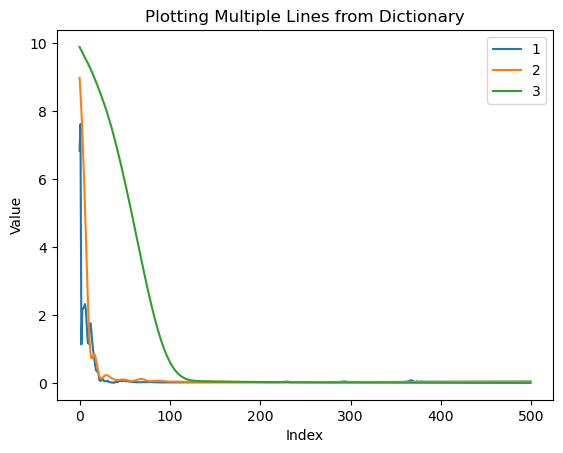

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


x = torch.tensor(3.0, requires_grad=True)
y = x**2 - 2*x
y.backward()
print(x.grad)
print(y)


# ---- 1. Synthetic data: y is a noisy linear function of 4 features ----
torch.manual_seed(0)
N = 50
X = torch.randn(N, 4)
true_w = torch.tensor([2.0, -3.0, 0.5, 1.0])
y = (X @ true_w + 0.1 * torch.randn(N)).unsqueeze(1)   # shape (N, 1)

# train / validation split
n_train = int(0.8*N)
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

# ---- 2. Model ----
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.LeakyReLU(0.2)
        self.fc3 = nn.Linear(hidden_dim, out_dim)
        self.act2 = nn.ReLU()
    def forward(self, x):
        return self.fc3(self.act2(self.fc2(self.act(self.fc1(x)))))

train_losses, val_losses = {}, {}
counter = 1
for i in [1e-1, 1e-2, 1e-3]:
    model = MLP(4, 32, 1)
    # ---- 3. Loss + optimizer ----
    loss_fn   = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=i)
    train_losses[counter], val_losses[counter] = [], []
    # ---- 4. Training loop ----
    for epoch in range(500):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val)

        train_losses[counter].append(loss.item())
        val_losses[counter].append(val_loss.item())
        #if epoch % 20 == 0:
        #    print(f"epoch {epoch:3d} | train {loss.item():.4f} | val {val_loss.item():.4f}")
    counter += 1
    
# Iterate through dictionary to plot each line
for label, values in val_losses.items():
    plt.plot(values, label=label)

# Add chart elements
plt.legend()  # Displays the dictionary keys as labels
plt.title("Plotting Multiple Lines from Dictionary")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

In [3]:
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

def make_vrp_graph(num_customers):
    """A random VRP-style instance as a Data object."""
    num_nodes = num_customers + 1                       # +1 for the depot
    coords = torch.rand(num_nodes, 2)
    demand = torch.zeros(num_nodes, 1)
    demand[1:] = torch.randint(1, 10, (num_customers, 1)).float()   # depot demand stays 0
    x = torch.cat([coords, demand], dim=1)              # [num_nodes, 3]

    edge_index = torch.tensor(
        [[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j],
        dtype=torch.long
    ).t().contiguous()

    src, dst = edge_index
    edge_attr = (coords[src] - coords[dst]).pow(2).sum(dim=1, keepdim=True).sqrt()
    y = torch.rand(1)                                   # placeholder target
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

graphs = [make_vrp_graph(n) for n in [3, 5, 4]]         # 4, 6, 5 nodes
loader = DataLoader(graphs, batch_size=2, shuffle=False)

for batch in loader:
    print(batch)
    print("  num_graphs:", batch.num_graphs)
    print("  batch vector:", batch.batch)

DataBatch(x=[10, 3], edge_index=[2, 42], edge_attr=[42, 1], y=[2], batch=[10], ptr=[3])
  num_graphs: 2
  batch vector: tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
DataBatch(x=[5, 3], edge_index=[2, 20], edge_attr=[20, 1], y=[1], batch=[5], ptr=[2])
  num_graphs: 1
  batch vector: tensor([0, 0, 0, 0, 0])


In [25]:
# Exercise 1 answer
import torch
from torch_geometric.data import Data

# Node features: [x_coord, y_coord, demand]. Depot has demand 0.
x = torch.tensor([
    [5.0, 5.0, 0.0],   # 0: depot
    [2.0, 8.0, 4.0],   # 1: customer
    [8.0, 8.0, 6.0],   # 2: customer
    [8.0, 2.0, 2.0],   # 3: customer
    [2.0, 2.0, 9.0]    # 4: customer
], dtype=torch.float)

num_nodes = x.size(0)

# Fully-connected directed edges: every (i, j) with i != j
edge_index = torch.tensor(
    [[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j],
    dtype=torch.long
).t().contiguous()                      # shape [2, 12]

# Edge feature = Euclidean distance between endpoints (vectorized)
coords = x[:, :2]                        # [4, 2]
src, dst = edge_index                    # each [12]
edge_attr = (coords[src] - coords[dst]).pow(2).sum(dim=1, keepdim=True).sqrt()  # [12, 1]

# Graph-level target — a placeholder "routing cost" scalar
y = torch.tensor([42.0])

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
print(data)
print("nodes:", data.num_nodes, "edges:", data.num_edges)


# Exercises 2+3 answer
def make_vrp_graph_asymmetric(num_customers, penalty):
    """A random VRP-style instance as a Data object."""
    num_nodes = num_customers + 1                       # +1 for the depot
    coords = torch.rand(num_nodes, 2)
    demand = torch.zeros(num_nodes, 1)
    demand[1:] = torch.randint(1, 10, (num_customers, 1)).float()   # depot demand stays 0
    x = torch.cat([coords, demand], dim=1)              # [num_nodes, 3]

    edge_index = torch.tensor(
        [[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j],
        dtype=torch.long
    ).t().contiguous()

    edge_attr_list = []
    for i, j in edge_index.t():
        # Convert tensor indices to integers
        i = i.item()
        j = j.item()
        # Coordinates
        xi, yi = coords[i][0], coords[i][1]
        xj, yj = coords[j][0], coords[j][1]
        # Euclidean distance
        distance = torch.sqrt((xi - xj)**2 + (yi - yj)**2)
        # Demands
        demand_i = demand[i]
        demand_j = demand[j]
        # Penalty condition
        extra_penalty = penalty if demand_i < demand_j else 0
        # Final edge feature
        edge_feature = distance + extra_penalty
        edge_attr_list.append([edge_feature])
    edge_attr = torch.tensor(edge_attr_list,
                             dtype=torch.float32)
    
    y = torch.rand(1)                                   # placeholder target
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

graphs = [make_vrp_graph_asymmetric(n, 10) for n in [3, 7, 4, 5, 6, 2]]
loader = DataLoader(graphs, batch_size=3, shuffle=False)

for batch in loader:
    print(batch)
    print("  num_graphs:", batch.num_graphs)
    print("  batch vector:", batch.batch)
    print("  Total node count:", len(batch.batch))

Data(x=[5, 3], edge_index=[2, 20], edge_attr=[20, 1], y=[1])
nodes: 5 edges: 20
DataBatch(x=[17, 3], edge_index=[2, 88], edge_attr=[88, 1], y=[3], batch=[17], ptr=[4])
  num_graphs: 3
  batch vector: tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])
DataBatch(x=[16, 3], edge_index=[2, 78], edge_attr=[78, 1], y=[3], batch=[16], ptr=[4])
  num_graphs: 3
  batch vector: tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2])


In [22]:
import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv, GCNConv
class DeepGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()

    def forward(self, x, edge_index):
        for conv in self.convs:
            x = self.act(conv(x, edge_index))
        return x
    
    
class exerc_1(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.act = nn.ReLU()

    def forward(self, x, edge_index):
        h1 = self.act(self.conv1(x, edge_index))
        h2 = self.act(self.conv2(h1, edge_index))
        h3 = self.act(self.conv3(h2, edge_index))
        return h1, h2, h3                       # return all three to inspect

data = make_vrp_graph(4)                        # 5 nodes, 3 node features

torch.manual_seed(0)
model = exerc_1(in_dim=3, hidden_dim=8)
h1, h2, h3 = model(data.x, data.edge_index)

print("input x    :", tuple(data.x.shape))     # (5, 3)
print("after conv1:", tuple(h1.shape))         # (5, 8)
print("after conv2:", tuple(h2.shape))         # (5, 8)
print("after conv3:", tuple(h3.shape))         # (5, 8)

print("\nnode 0 input     :", data.x[0])
print("node 0 after conv1:", h1[0])
print("node 0 after conv2:", h2[0])
print("node 0 after conv3:", h3[0])

input x    : (5, 3)
after conv1: (5, 8)
after conv2: (5, 8)
after conv3: (5, 8)

node 0 input     : tensor([0.0498, 0.6148, 0.0000])
node 0 after conv1: tensor([1.4508, 0.0000, 0.0000, 0.0000, 0.8322, 0.0000, 0.0000, 0.9986],
       grad_fn=<SelectBackward0>)
node 0 after conv2: tensor([0.0000, 0.0000, 0.0000, 0.4632, 0.0000, 0.0000, 0.0000, 0.0474],
       grad_fn=<SelectBackward0>)
node 0 after conv3: tensor([0.0000, 0.0267, 0.0000, 0.0701, 0.0000, 0.2347, 0.0780, 0.0000],
       grad_fn=<SelectBackward0>)


In [21]:
model2 = DeepGNN(in_dim=3, hidden_dim=8, num_layers = 4)
x2 = model2(data.x, data.edge_index)

print(xx)

tensor([[0.0419, 0.0000, 0.1539, 0.4076, 0.2259, 0.0000, 0.4154, 0.0000],
        [0.0500, 0.0000, 0.2168, 0.4070, 0.1386, 0.0000, 0.4484, 0.0000],
        [0.0465, 0.0000, 0.1706, 0.4059, 0.2122, 0.0000, 0.4200, 0.0000],
        [0.0445, 0.0000, 0.1750, 0.4057, 0.2082, 0.0000, 0.4241, 0.0000],
        [0.0357, 0.0000, 0.1524, 0.4019, 0.2192, 0.0000, 0.4246, 0.0000]],
       grad_fn=<ReluBackward0>)


epoch   0 | train 4.049 | val 4.122
epoch  10 | train 0.370 | val 0.458
epoch  20 | train 0.257 | val 0.297
epoch  30 | train 0.288 | val 0.335
epoch  40 | train 0.239 | val 0.291
epoch  50 | train 0.259 | val 0.286
epoch  60 | train 0.245 | val 0.285
epoch  70 | train 0.176 | val 0.211
epoch  80 | train 0.149 | val 0.184
epoch  90 | train 0.190 | val 0.214
epoch 100 | train 0.132 | val 0.171
epoch 110 | train 0.146 | val 0.173
epoch 120 | train 0.133 | val 0.162
epoch 130 | train 0.105 | val 0.138
epoch 140 | train 0.137 | val 0.170
Early stopping at epoch 144

Test MSE: 0.098


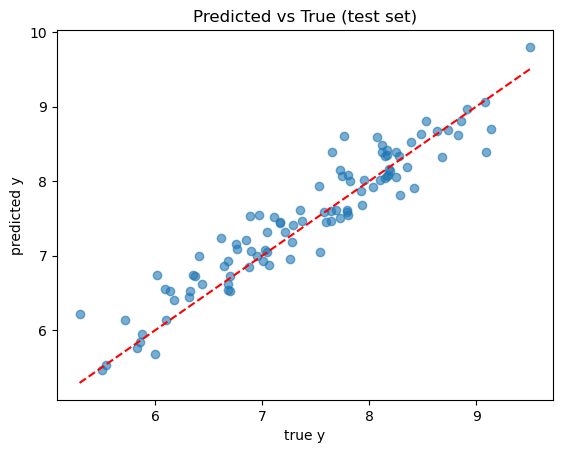

In [41]:
import torch
import torch.nn as nn
import copy
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool


class GraphRegressor(nn.Module):
    def __init__(self, node_in_dim, hidden_dim):
        super().__init__()
        # 1. initial embedding: raw node features -> hidden space
        self.embed = nn.Linear(node_in_dim, hidden_dim)
        # 2. encoder: stack of message-passing layers
        self.conv1 = SAGEConv(hidden_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        # 4. regression head: graph vector -> scalar
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.act = nn.ReLU()

    def forward(self, x, edge_index, batch):
        h = self.act(self.embed(x))             # 1. initial embedding
        h = self.act(self.conv1(h, edge_index)) # 2. encoder
        h = self.act(self.conv2(h, edge_index))
        hg = global_max_pool(h, batch)         # 3. readout: per-graph pooling
        return self.head(hg)                    # 4. head -> [num_graphs, 1]

# ---------- dataset: graphs with a learnable target ----------
def make_graph_with_target(num_customers):
    num_nodes = num_customers + 1
    coords = torch.rand(num_nodes, 2)
    demand = torch.zeros(num_nodes, 1)
    demand[1:] = torch.randint(1, 10, (num_customers, 1)).float()
    x = torch.cat([coords, demand], dim=1)

    edge_index = torch.tensor(
        [[i, j] for i in range(num_nodes) for j in range(num_nodes) if i != j],
        dtype=torch.long
    ).t().contiguous()
    src, dst = edge_index
    edge_attr = (coords[src] - coords[dst]).pow(2).sum(dim=1, keepdim=True).sqrt()

    # target = average customer demand + 5 * average distance from depot + noise
    mean_demand = demand[1:].mean()
    avg_dist_to_depot = (coords[1:] - coords[0]).pow(2).sum(dim=1).sqrt().mean()
    y = (mean_demand + 5.0 * avg_dist_to_depot).view(1) + 0.1 * torch.randn(1)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

torch.manual_seed(0)
dataset = [make_graph_with_target(torch.randint(5, 15, (1,)).item()) for _ in range(600)]

# ---------- split BY GRAPH ----------
train_set, val_set, test_set = dataset[:400], dataset[400:500], dataset[500:]
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

# ---------- model / loss / optimizer ----------
model     = GraphRegressor(node_in_dim=3, hidden_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn   = nn.MSELoss()

# ---------- evaluation helper (average per-graph loss over a loader) ----------
def evaluate(loader):
    model.eval()
    total_loss, total_graphs = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(pred, batch.y.view(-1, 1))
            total_loss += loss.item() * batch.num_graphs   # weight by batch size
            total_graphs += batch.num_graphs
    return total_loss / total_graphs

# ---------- training loop with early stopping ----------
best_val, best_state, patience, counter = float('inf'), None, 20, 0
train_curve, val_curve = [], []

for epoch in range(200):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(pred, batch.y.view(-1, 1))
        loss.backward()
        optimizer.step()

    train_loss, val_loss = evaluate(train_loader), evaluate(val_loader)
    train_curve.append(train_loss); val_curve.append(val_loss)

    if val_loss < best_val:
        best_val, best_state, counter = val_loss, copy.deepcopy(model.state_dict()), 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d} | train {train_loss:.3f} | val {val_loss:.3f}")

model.load_state_dict(best_state)   # restore best weights

# ---------- test evaluation + predicted-vs-true scatter ----------
print(f"\nTest MSE: {evaluate(test_loader):.3f}")

model.eval()
preds, trues = [], []
with torch.no_grad():
    for batch in test_loader:
        preds.append(model(batch.x, batch.edge_index, batch.batch).view(-1))
        trues.append(batch.y.view(-1))
preds, trues = torch.cat(preds).numpy(), torch.cat(trues).numpy()

plt.scatter(trues, preds, alpha=0.6)
plt.plot([trues.min(), trues.max()], [trues.min(), trues.max()], 'r--')
plt.xlabel("true y"); plt.ylabel("predicted y"); plt.title("Predicted vs True (test set)")
plt.show()

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphConv, global_mean_pool
from torch_geometric.utils import erdos_renyi_graph

torch.manual_seed(0)
D_IN = 4
W_TRUE = torch.randn(D_IN)            # fixed projection defining the target

def make_graph(n_min=8, n_max=20, p=0.25):
    N = torch.randint(n_min, n_max + 1, (1,)).item()
    edge_index = erdos_renyi_graph(N, p)          # undirected, no self-loops
    x = torch.randn(N, D_IN)
    v = x @ W_TRUE                                 # [N] per-node scalar
    row, col = edge_index                          # edges j(col) -> i(row)
    agg = torch.zeros(N).index_add_(0, row, v[col])# sum of neighbour values
    y = agg.mean().reshape(1)                      # graph-level scalar [1]
    return Data(x=x, edge_index=edge_index, y=y)

dataset    = [make_graph() for _ in range(2000)]
train, val = dataset[:1600], dataset[1600:]
train_loader = DataLoader(train, batch_size=32, shuffle=True)   # B = 32
val_loader   = DataLoader(val,   batch_size=64)

class GraphRegressor(nn.Module):
    def __init__(self, d_in, d_h=32, n_layers=2):
        super().__init__()
        self.encoder = nn.Linear(d_in, d_h)                       # d_in -> d_h
        self.convs   = nn.ModuleList(
            [GraphConv(d_h, d_h, aggr='add') for _ in range(n_layers)]
        )
        self.decoder = nn.Sequential(                             # d_h -> 1
            nn.Linear(d_h, d_h), nn.ReLU(), nn.Linear(d_h, 1)
        )

    def forward(self, data):
        h = self.encoder(data.x)                                  # [N, d_h]
        for conv in self.convs:
            h = F.relu(conv(h, data.edge_index))                  # [N, d_h]
        h_g = global_mean_pool(h, data.batch)                     # [B, d_h]
        return self.decoder(h_g).squeeze(-1)                      # [B]

model   = GraphRegressor(D_IN, d_h=32, n_layers=2)
opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, 51):
    model.train()
    for batch in train_loader:
        opt.zero_grad()
        loss = loss_fn(model(batch), batch.y)
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        mae = sum(F.l1_loss(model(b), b.y, reduction='sum') for b in val_loader)
        mae = mae / len(val)
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}   val MAE {mae:.4f}")

epoch  10   val MAE 0.1285
epoch  20   val MAE 0.0831
epoch  30   val MAE 0.0575
epoch  40   val MAE 0.0547
epoch  50   val MAE 0.0499


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool
from torch_geometric.utils import erdos_renyi_graph

torch.manual_seed(0)
D_IN, D_H, HEADS, N_LAYERS = 4, 32, 4, 2     # d_h divisible by heads

def make_graph(n_min=8, n_max=20, p=0.2):
    N = torch.randint(n_min, n_max + 1, (1,)).item()
    edge_index = erdos_renyi_graph(N, p)              # undirected
    x = torch.randn(N, D_IN)
    s, val = x[:, 0], x[:, 1]                         # salience, value
    row, col = edge_index                             # edge col -> row
    q = torch.zeros(N)
    for i in range(N):
        nbrs = col[row == i]                          # neighbours of i
        if len(nbrs) > 0:
            q[i] = val[nbrs[s[nbrs].argmax()]]        # value of max-salience nbr
    y = q.mean().reshape(1)
    return Data(x=x, edge_index=edge_index, y=y)

dataset    = [make_graph() for _ in range(2000)]
train, val = dataset[:1600], dataset[1600:]
train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val,   batch_size=64)

class GATRegressor(nn.Module):
    def __init__(self, d_in, d_h=D_H, heads=HEADS, n_layers=N_LAYERS):
        super().__init__()
        self.encoder = nn.Linear(d_in, d_h)                       # d_in -> d_h
        self.convs   = nn.ModuleList([
            GATv2Conv(d_h, d_h // heads, heads=heads,             # per-head d_k = d_h/H
                      concat=True, add_self_loops=False)          # concat -> back to d_h
            for _ in range(n_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(d_h, d_h), nn.ReLU(), nn.Linear(d_h, 1)
        )

    def forward(self, data):
        h = self.encoder(data.x)                                  # [N, d_h]
        for conv in self.convs:
            h = F.elu(conv(h, data.edge_index))                   # [N, d_h]
        h_g = global_mean_pool(h, data.batch)                     # [B, d_h]
        return self.decoder(h_g).squeeze(-1)                      # [B]

model   = GATRegressor(D_IN)
opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, 81):
    model.train()
    for batch in train_loader:
        opt.zero_grad()
        loss = loss_fn(model(batch), batch.y)
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        mae = sum(F.l1_loss(model(b), b.y, reduction='sum') for b in val_loader)
        mae = mae / len(val)
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}   val MAE {mae:.4f}")

epoch  20   val MAE 0.1155
epoch  40   val MAE 0.1082
epoch  60   val MAE 0.0979
epoch  80   val MAE 0.0978


In [2]:
########################################################################
# GRAPH ATTENTION NETWORK (GAT) FOR GRAPH-LEVEL REGRESSION
#
# This example demonstrates:
#
# 1. Random graph generation
# 2. Node features:
#       - demand
#       - prize
#       - penalty
#       - release time
#       - deadline
#
# 3. Edge features:
#       - distance
#       - travel time
#
# 4. Global feature:
#       - vehicle capacity
#
# 5. Feature normalization
# 6. Feature encoding
# 7. GAT with 3 layers
# 8. Graph-level regression
# 9. Adam optimizer
#
########################################################################

import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch_geometric.nn import (
    GATConv,
    global_mean_pool
)

########################################################################
# RANDOM SEED
########################################################################

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

########################################################################
# PARAMETERS
########################################################################

NUM_GRAPHS = 300

MIN_NODES = 8
MAX_NODES = 20

########################################################################
# GENERATE RANDOM GRAPH
########################################################################

def generate_random_graph():

    ###############################################################
    # NUMBER OF NODES
    ###############################################################

    num_nodes = random.randint(
        MIN_NODES,
        MAX_NODES
    )

    ###############################################################
    # RANDOM NODE COORDINATES
    ###############################################################

    coords = np.random.uniform(
        low=0,
        high=100,
        size=(num_nodes, 2)
    )

    ###############################################################
    # NODE FEATURES
    ###############################################################

    demands = np.random.uniform(
        1,
        20,
        size=(num_nodes, 1)
    )

    prizes = np.random.uniform(
        5,
        100,
        size=(num_nodes, 1)
    )

    penalties = np.random.uniform(
        1,
        50,
        size=(num_nodes, 1)
    )

    ###############################################################
    # TIME WINDOWS
    ###############################################################

    release_times = np.random.uniform(
        0,
        50,
        size=(num_nodes, 1)
    )

    window_widths = np.random.uniform(
        10,
        40,
        size=(num_nodes, 1)
    )

    deadlines = release_times + window_widths

    ###############################################################
    # DERIVED FEATURE
    ###############################################################

    time_window_lengths = deadlines - release_times

    ###############################################################
    # GLOBAL FEATURE
    ###############################################################

    total_demand = np.sum(demands)

    vehicle_capacity = (
        total_demand / 4
        + np.random.normal(0, 5)
    )

    ###############################################################
    # BUILD FULLY CONNECTED GRAPH
    ###############################################################

    edge_index = []
    edge_attr = []

    for i in range(num_nodes):

        for j in range(num_nodes):

            if i == j:
                continue

            #######################################################
            # EUCLIDEAN DISTANCE
            #######################################################

            dist = np.linalg.norm(
                coords[i] - coords[j]
            )

            #######################################################
            # TRAVEL TIME
            #######################################################

            travel_time = (
                dist / np.random.uniform(0.8, 1.5)
            )

            edge_index.append([i, j])

            edge_attr.append([
                dist,
                travel_time
            ])

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    edge_attr = torch.tensor(
        edge_attr,
        dtype=torch.float
    )

    ###############################################################
    # NODE FEATURE MATRIX
    ###############################################################

    node_features = np.concatenate([

        demands,
        prizes,
        penalties,
        release_times,
        deadlines,
        time_window_lengths

    ], axis=1)

    x = torch.tensor(
        node_features,
        dtype=torch.float
    )

    ###############################################################
    # DUMMY REGRESSION TARGET
    #
    # y = SUM(
    #     prize_j * distance_from_depot
    #     / time_window_length
    # ) + noise
    ###############################################################

    depot = coords[0]

    target = 0

    for j in range(1, num_nodes):

        depot_distance = np.linalg.norm(
            coords[j] - depot
        )

        target += (
            prizes[j][0]
            * depot_distance
            / time_window_lengths[j][0]
        )

    ###############################################################
    # ADD NOISE
    ###############################################################

    target += np.random.normal(0, 20)

    y = torch.tensor(
        [target],
        dtype=torch.float
    )

    ###############################################################
    # CREATE PYG DATA OBJECT
    ###############################################################

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

    ###############################################################
    # GLOBAL FEATURE
    ###############################################################

    data.global_features = torch.tensor(
        [[vehicle_capacity]],
        dtype=torch.float
    )

    return data

########################################################################
# CREATE DATASET
########################################################################

dataset = [
    generate_random_graph()
    for _ in range(NUM_GRAPHS)
]

########################################################################
# NORMALIZATION
#
# VERY IMPORTANT:
# We normalize:
#
# 1. Node features
# 2. Edge features
# 3. Global features
# 4. Targets
########################################################################

###############################################################
# COLLECT FEATURES
###############################################################

all_node_features = np.concatenate([
    graph.x.numpy()
    for graph in dataset
], axis=0)

all_edge_features = np.concatenate([
    graph.edge_attr.numpy()
    for graph in dataset
], axis=0)

all_global_features = np.concatenate([
    graph.global_features.numpy()
    for graph in dataset
], axis=0)

all_targets = np.concatenate([
    graph.y.numpy()
    for graph in dataset
], axis=0)

###############################################################
# FIT SCALERS
###############################################################

node_scaler = StandardScaler()
edge_scaler = StandardScaler()
global_scaler = StandardScaler()
target_scaler = StandardScaler()

node_scaler.fit(all_node_features)
edge_scaler.fit(all_edge_features)
global_scaler.fit(all_global_features)
target_scaler.fit(all_targets.reshape(-1, 1))

###############################################################
# APPLY NORMALIZATION
###############################################################

for graph in dataset:

    graph.x = torch.tensor(
        node_scaler.transform(graph.x.numpy()),
        dtype=torch.float
    )

    graph.edge_attr = torch.tensor(
        edge_scaler.transform(
            graph.edge_attr.numpy()
        ),
        dtype=torch.float
    )

    graph.global_features = torch.tensor(
        global_scaler.transform(
            graph.global_features.numpy()
        ),
        dtype=torch.float
    )

    graph.y = torch.tensor(
        target_scaler.transform(
            graph.y.numpy().reshape(-1, 1)
        ).flatten(),
        dtype=torch.float
    )

########################################################################
# TRAIN / TEST SPLIT
########################################################################

train_dataset = dataset[:250]
test_dataset = dataset[250:]

########################################################################
# DATALOADER
########################################################################

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

########################################################################
# FEATURE ENCODERS
########################################################################

class NodeEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        ############################################################
        # NODE FEATURES:
        #
        # [demand,
        #  prize,
        #  penalty,
        #  release,
        #  deadline,
        #  width]
        ############################################################

        self.encoder = nn.Sequential(

            nn.Linear(6, 32),

            nn.ReLU(),

            nn.Linear(32, 32)
        )

    def forward(self, x):

        return self.encoder(x)

########################################################################
# GAT MODEL
########################################################################

class GATGraphRegressor(nn.Module):

    def __init__(self):

        super().__init__()

        ############################################################
        # NODE FEATURE ENCODER
        ############################################################

        self.node_encoder = NodeEncoder()

        ############################################################
        # GAT LAYERS
        #
        # 3 LAYERS
        ############################################################

        self.gat1 = GATConv(
            in_channels=32,
            out_channels=32,
            heads=4,
            concat=True,
            edge_dim=2,
            dropout=0.2
        )

        self.gat2 = GATConv(
            in_channels=128,
            out_channels=32,
            heads=4,
            concat=True,
            edge_dim=2,
            dropout=0.2
        )

        self.gat3 = GATConv(
            in_channels=128,
            out_channels=32,
            heads=4,
            concat=False,
            edge_dim=2,
            dropout=0.2
        )

        ############################################################
        # FINAL MLP
        ############################################################

        self.mlp = nn.Sequential(

            nn.Linear(32 + 1, 64),

            nn.ReLU(),

            nn.Linear(64, 1)
        )

    ####################################################################
    # FORWARD
    ####################################################################

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        global_features = data.global_features

        ############################################################
        # ENCODE NODE FEATURES
        ############################################################

        x = self.node_encoder(x)

        ############################################################
        # GAT LAYER 1
        ############################################################

        x = self.gat1(
            x,
            edge_index,
            edge_attr=edge_attr
        )

        x = F.elu(x)

        ############################################################
        # GAT LAYER 2
        ############################################################

        x = self.gat2(
            x,
            edge_index,
            edge_attr=edge_attr
        )

        x = F.elu(x)

        ############################################################
        # GAT LAYER 3
        ############################################################

        x = self.gat3(
            x,
            edge_index,
            edge_attr=edge_attr
        )

        x = F.elu(x)

        ############################################################
        # GRAPH POOLING
        ############################################################

        graph_embedding = global_mean_pool(
            x,
            batch
        )

        ############################################################
        # CONCAT GLOBAL FEATURE
        ############################################################

        graph_embedding = torch.cat([
            graph_embedding,
            global_features
        ], dim=1)

        ############################################################
        # FINAL REGRESSION
        ############################################################

        out = self.mlp(graph_embedding)

        return out.squeeze()

########################################################################
# DEVICE
########################################################################

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

########################################################################
# MODEL
########################################################################

model = GATGraphRegressor().to(device)

########################################################################
# LOSS FUNCTION
########################################################################

criterion = nn.MSELoss()

########################################################################
# ADAM OPTIMIZER
########################################################################

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

########################################################################
# TRAINING LOOP
########################################################################

NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0

    ###############################################################
    # TRAINING
    ###############################################################

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        predictions = model(batch)

        loss = criterion(
            predictions,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    ###############################################################
    # PRINT LOSS
    ###############################################################

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Training Loss: {avg_loss:.4f}"
    )

########################################################################
# EVALUATION
########################################################################

model.eval()

test_loss = 0

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        predictions = model(batch)

        loss = criterion(
            predictions,
            batch.y
        )

        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)

print("\nFinal Test Loss:", avg_test_loss)

########################################################################
# IMPORTANT NOTES
########################################################################

"""
FEATURES USED
==============

NODE FEATURES
--------------
1. demand
2. prize
3. penalty
4. release time
5. deadline
6. time window width

EDGE FEATURES
--------------
1. distance
2. travel time

GLOBAL FEATURE
---------------
1. vehicle capacity


ENCODING STRATEGY
=================

Continuous features:
    -> StandardScaler normalization
    -> MLP encoder


GAT ARCHITECTURE
================

3 GAT layers

Layer 1:
    concat=True
    heads=4

Layer 2:
    concat=True
    heads=4

Layer 3:
    concat=False
    heads=4


WHY concat=False IN FINAL LAYER?
================================

Produces more stable graph embeddings.


TARGET FUNCTION
===============

Synthetic regression target:

SUM(
    prize_j
    *
    distance_from_depot
    /
    time_window_length_j
)
+
noise


IMPORTANT PRACTICAL LESSONS
===========================

1. Normalize ALL continuous features
2. Include derived features
3. Use edge features
4. Use graph/global features
5. Use mean pooling as strong baseline
6. Use ELU/ReLU in GAT
7. Use dropout for stability

"""

Epoch 001 | Training Loss: 0.9830
Epoch 002 | Training Loss: 0.8368
Epoch 003 | Training Loss: 0.7791
Epoch 004 | Training Loss: 0.7501
Epoch 005 | Training Loss: 0.6269
Epoch 006 | Training Loss: 0.5366
Epoch 007 | Training Loss: 0.4787
Epoch 008 | Training Loss: 0.4540
Epoch 009 | Training Loss: 0.4734
Epoch 010 | Training Loss: 0.4370
Epoch 011 | Training Loss: 0.4182
Epoch 012 | Training Loss: 0.4013
Epoch 013 | Training Loss: 0.3998
Epoch 014 | Training Loss: 0.3867
Epoch 015 | Training Loss: 0.3935
Epoch 016 | Training Loss: 0.3937
Epoch 017 | Training Loss: 0.3833
Epoch 018 | Training Loss: 0.3831
Epoch 019 | Training Loss: 0.3809
Epoch 020 | Training Loss: 0.3687
Epoch 021 | Training Loss: 0.3733
Epoch 022 | Training Loss: 0.3713
Epoch 023 | Training Loss: 0.3716
Epoch 024 | Training Loss: 0.3667
Epoch 025 | Training Loss: 0.3566
Epoch 026 | Training Loss: 0.3777
Epoch 027 | Training Loss: 0.3791
Epoch 028 | Training Loss: 0.3416
Epoch 029 | Training Loss: 0.3674
Epoch 030 | Tr

'\nFEATURES USED\n==============\n\nNODE FEATURES\n--------------\n1. demand\n2. prize\n3. penalty\n4. release time\n5. deadline\n6. time window width\n\nEDGE FEATURES\n--------------\n1. distance\n2. travel time\n\nGLOBAL FEATURE\n---------------\n1. vehicle capacity\n\n\nENCODING STRATEGY\n=================\n\nContinuous features:\n    -> StandardScaler normalization\n    -> MLP encoder\n\n\nGAT ARCHITECTURE\n================\n\n3 GAT layers\n\nLayer 1:\n    concat=True\n    heads=4\n\nLayer 2:\n    concat=True\n    heads=4\n\nLayer 3:\n    concat=False\n    heads=4\n\n\nWHY concat=False IN FINAL LAYER?\n================================\n\nProduces more stable graph embeddings.\n\n\nTARGET FUNCTION\n===============\n\nSynthetic regression target:\n\nSUM(\n    prize_j\n    *\n    distance_from_depot\n    /\n    time_window_length_j\n)\n+\nnoise\n\n\nIMPORTANT PRACTICAL LESSONS\n===========================\n\n1. Normalize ALL continuous features\n2. Include derived features\n3. Use edg